##Student Name: U G P G Mihiranga
##Student ID: IT23153486
##Model:Deep Embedded Forest (DEF) model

In [19]:
%pip install pandas scikit-learn numpy tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.ensemble import RandomForestClassifier

In [21]:
# --- 1. Load and Clean the Data ---
df = pd.read_csv("Cancer_Data.csv")

# Drop unnecessary columns: 'id' (identifier) and 'Unnamed: 32' (all NaN)
df = df.drop(['id', 'Unnamed: 32'], axis=1)

In [22]:
# --- 2. Target Encoding ---
# Encode 'diagnosis' (Malignant/Benign) to 1/0
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])
# M is typically 1, B is typically 0, confirmed in the execution output.

In [23]:
# --- 3. Feature/Target Separation (MISSING STEP ADDED) ---
# Define X (features) as all columns except 'diagnosis'
X = df.drop('diagnosis', axis=1)
# Define y (target) as the 'diagnosis' column
y = df['diagnosis']

In [24]:
# --- 4. Split Data ---
# Stratify ensures the train/test split has the same proportion of M/B
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# --- 5. Feature Scaling (Crucial for the Deep Learning Component) ---
# Use StandardScaler (Z-score normalization)
scaler = StandardScaler()

# Fit scaler on X_train and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Convert back to NumPy arrays (needed for TensorFlow/Keras)
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [27]:
# --- Stage 1: Deep Embedding Network ---

# Define the input shape
input_shape = X_train_scaled.shape[1] # 30 features
embedding_dim = 16 # The size of the compressed feature representation

In [28]:
# 1. Feature Extractor (Embedding) Layers
input_layer = Input(shape=(input_shape,), name='input_features')
h = Dense(64, activation='relu', name='dense_64')(input_layer)
h = Dropout(0.2)(h)
# This bottleneck layer will be the output of our embedder
embedding_layer = Dense(embedding_dim, activation='relu', name='embedding_16')(h)
h = Dropout(0.2)(embedding_layer)

In [29]:
# 2. Classification Head
output_layer = Dense(1, activation='sigmoid', name='output_diagnosis')(h)

# Full Classifier Model
classifier_model = Model(inputs=input_layer, outputs=output_layer)

# Compile and train the classifier model
classifier_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
# Train the model (e.g., 50-100 epochs with early stopping)
classifier_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.7099 - loss: 0.5403 - val_accuracy: 0.8596 - val_loss: 0.3725
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8967 - loss: 0.3322 - val_accuracy: 0.9123 - val_loss: 0.2495
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9341 - loss: 0.2307 - val_accuracy: 0.9386 - val_loss: 0.1850
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9516 - loss: 0.1771 - val_accuracy: 0.9474 - val_loss: 0.1424
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9582 - loss: 0.1523 - val_accuracy: 0.9737 - val_loss: 0.1152
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9516 - loss: 0.1439 - val_accuracy: 0.9825 - val_loss: 0.0992
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9648 - loss: 0.1076 - val_accuracy: 0.9825 - val_loss: 0.0886
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9582 - loss: 0.1102 - val_accuracy: 0.9912 - val_l

In [31]:
# --- Extract the Feature Embedder ---
# Create a new model that outputs the feature embedding instead of the diagnosis
feature_embedder = Model(inputs=input_layer, outputs=embedding_layer)

# Generate new, embedded features
X_train_embedded = feature_embedder.predict(X_train_scaled)
X_test_embedded = feature_embedder.predict(X_test_scaled)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


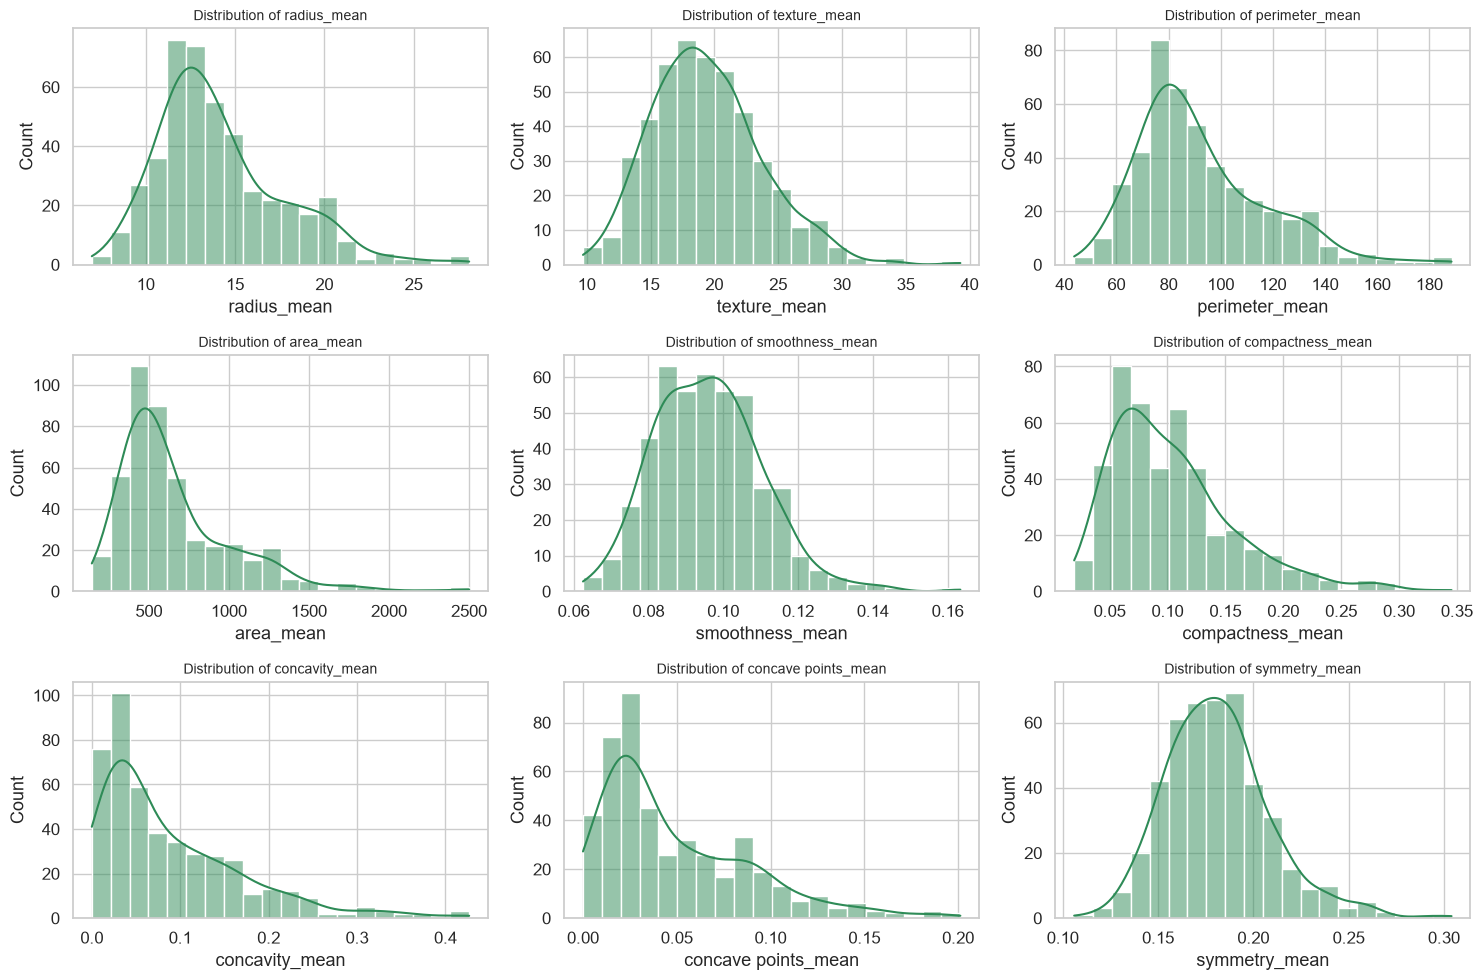

C:\Users\HP\AppData\Local\Temp\ipykernel_7736\3432262103.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


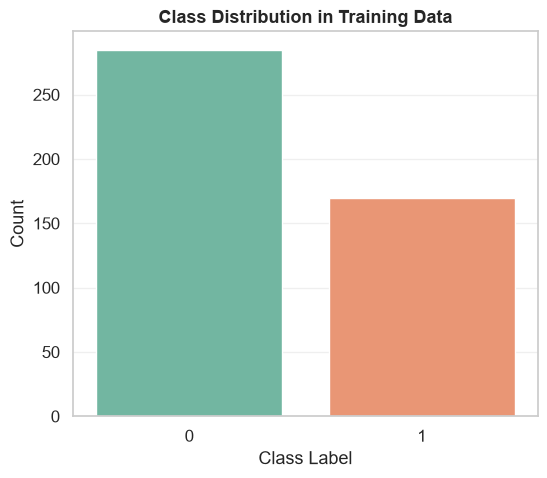

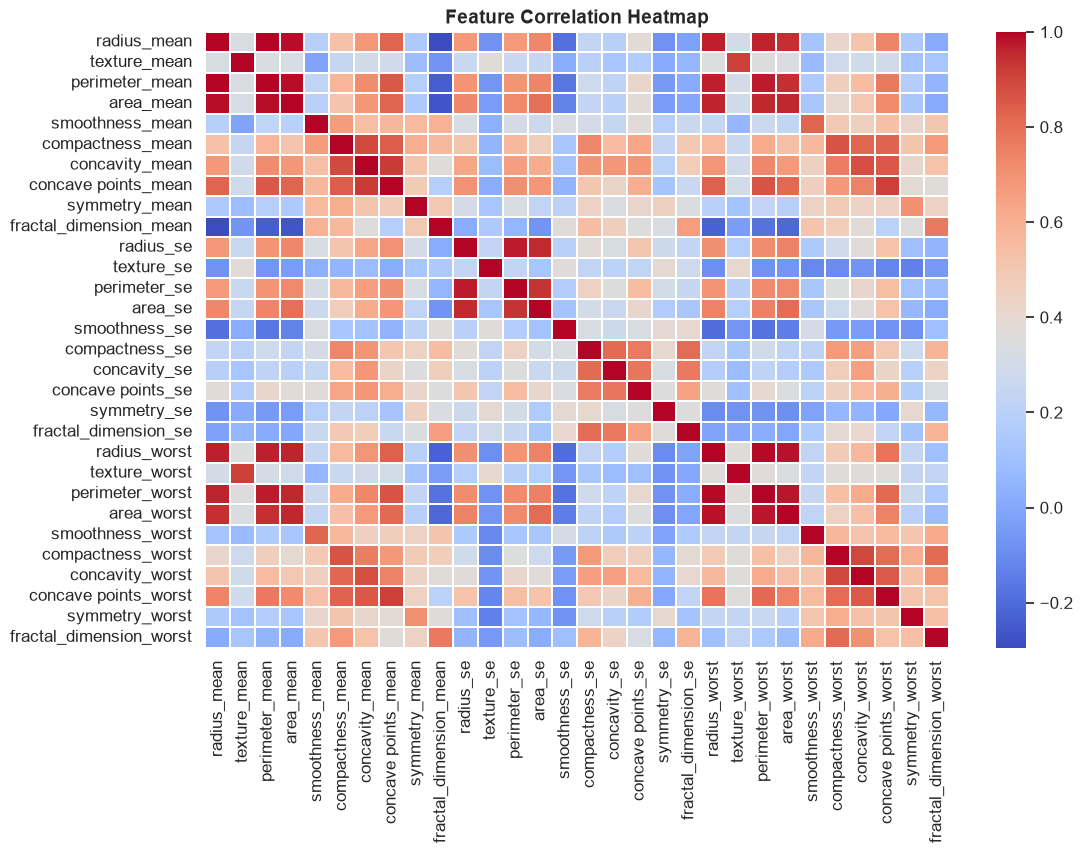

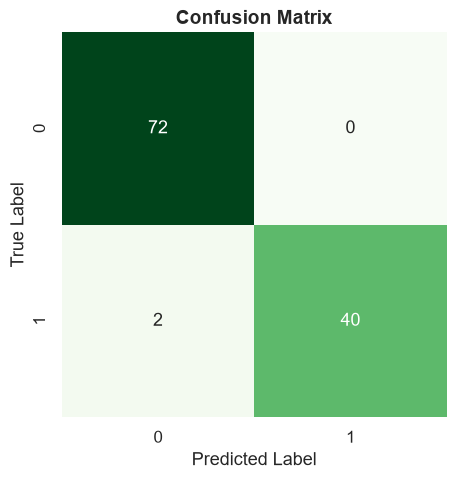

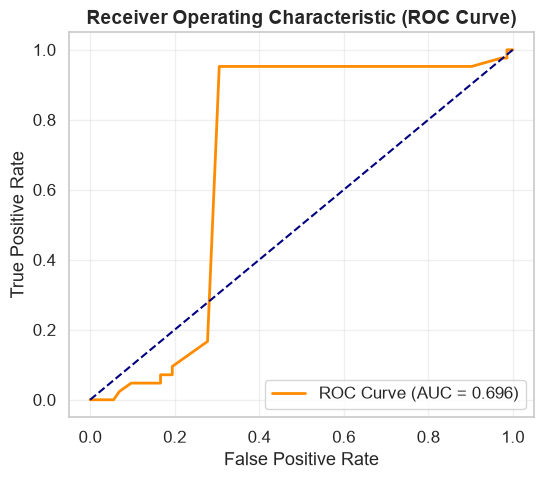

C:\Users\HP\AppData\Local\Temp\ipykernel_7736\3432262103.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:15], y=X_train.columns[indices][:15], palette="crest")


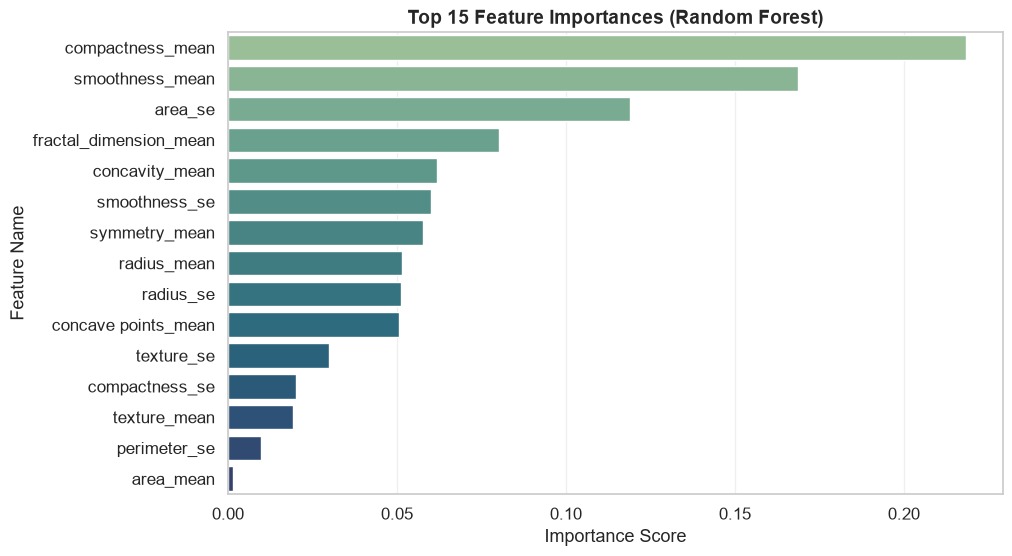

Random Forest Model Evaluation Summary

✅ Test Accuracy: 0.9825

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [32]:
# --- Visualization & Model Evaluation Section for Random Forest Classifier ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
)
import numpy as np
import pandas as pd

# Ensure plots have a consistent style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ---------------------------------------------------------------
# 1️⃣ Distribution of Features
# ---------------------------------------------------------------
plt.figure(figsize=(15, 10))
for i, col in enumerate(X_train.columns[:9]):  # plot first 9 features (for readability)
    plt.subplot(3, 3, i+1)
    sns.histplot(X_train[col], bins=20, kde=True, color='seagreen')
    plt.title(f"Distribution of {col}", fontsize=10)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 2️⃣ Class Imbalance Visualization
# ---------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.countplot(x=y_train, palette="Set2")
plt.title("Class Distribution in Training Data", fontsize=13, fontweight="bold")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

# ---------------------------------------------------------------
# 3️⃣ Correlation Heatmap
# ---------------------------------------------------------------
plt.figure(figsize=(12, 8))
corr = pd.DataFrame(X_train, columns=X_train.columns).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.3)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

# ---------------------------------------------------------------
# 4️⃣ Confusion Matrix
# ---------------------------------------------------------------
cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, square=True)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ---------------------------------------------------------------
# 5️⃣ ROC Curve (Fixed version for embedded test set)
# ---------------------------------------------------------------
if len(np.unique(y_test)) == 2:  # binary classification check
    try:
        y_prob = rf_model.predict_proba(X_test_embedded)[:, 1]
    except Exception as e:
        print("Error during ROC computation:", e)
        y_prob = None

    if y_prob is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC Curve)", fontsize=14, fontweight="bold")
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()


# ---------------------------------------------------------------
# 6️⃣ Feature Importance
# ---------------------------------------------------------------
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:15], y=X_train.columns[indices][:15], palette="crest")
plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.grid(axis='x', alpha=0.3)
plt.show()

# ---------------------------------------------------------------
# 7️⃣ Classification Report & Accuracy
# ---------------------------------------------------------------
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Model Evaluation Summary\n")
print(f"✅ Test Accuracy: {rf_accuracy:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, rf_predictions))
